# Task 4 -- Control Sweeps, Single Rotor (Sec 4)

All at one representative helicopter-mode forward-flight condition, single rotor, no trim solver needed (Track A's control sweeps are independent of Track B/C by design).

**4.1** Collective sweep at zero cyclic: T, Q, P vs. theta0.

**4.2** Longitudinal cyclic (theta_1c) sweep at fixed collective: shows the rigid-hub PITCHING moment response (a consequence of the "no flapping" assumption -- see `edgewise_bemt.py`). Thrust and torque barely move; the moment does, a lot -- this asymmetry is the result worth discussing.

**4.3** Lateral cyclic (theta_1s) sweep at fixed collective: same idea for the ROLLING moment.

In [1]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from task5_tiltrotor_design import TILTROTOR_GEOM, TILTROTOR_AIRFOIL, RPM_HOVER
from edgewise_bemt import EdgewiseFlightCondition, EdgewiseBEMTSolver

FIG_DIR = "figures"
OUT_DIR = "outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

solver = EdgewiseBEMTSolver(TILTROTOR_GEOM, TILTROTOR_AIRFOIL)

# Same condition as task2/task3's demo point, so the report can cross-reference
# one consistent operating point across Sec 2, 3 and 4.
BASE_COLLECTIVE_DEG = 14.0
V_EDGE = 30.0
V_AXIAL = 0.0
base_flight = EdgewiseFlightCondition.from_rpm(RPM_HOVER, BASE_COLLECTIVE_DEG,
                                                V_axial=V_AXIAL, V_edge=V_EDGE)

def save_csv(sweep, keys, path):
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(keys)
        n = len(sweep[keys[0]])
        for i in range(n):
            writer.writerow([sweep[k][i] for k in keys])

## 4.1 -- Collective sweep

Starts at 12 deg, not lower: below that the underlying M1 axial bisection (used for the baseline inflow) fails to bracket a root for this rotor/airfoil combination.

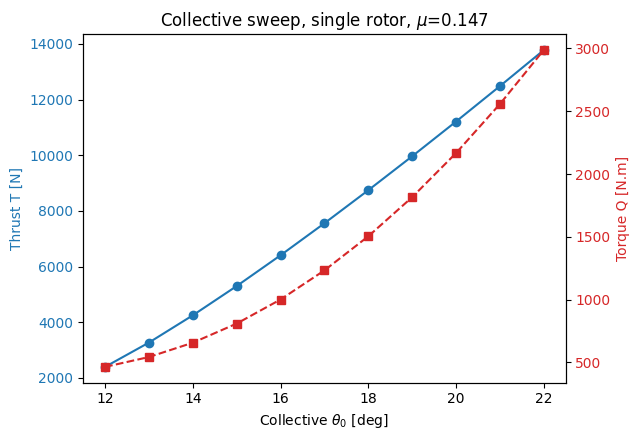

T range: 2395 to 13778 N
Reverse-flow fraction range: 0.12% to 0.12%


In [2]:
coll_range = np.arange(12.0, 22.0 + 1e-6, 1.0)
sweep = solver.sweep_collective(coll_range, base_flight)
save_csv(sweep, ["collective_deg", "T", "Q", "P", "CT", "CQ", "CP",
                  "reverse_flow_fraction", "stall_fraction", "M_adv_tip"],
          os.path.join(OUT_DIR, "task4_1_collective_sweep.csv"))

fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
ax1.plot(sweep["collective_deg"], sweep["T"], "o-", color="tab:blue", label="Thrust T")
ax1.set_xlabel(r"Collective $\theta_0$ [deg]")
ax1.set_ylabel("Thrust T [N]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.plot(sweep["collective_deg"], sweep["Q"], "s--", color="tab:red", label="Torque Q")
ax2.set_ylabel("Torque Q [N.m]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
mu_base = base_flight.V_edge/(base_flight.Omega*TILTROTOR_GEOM.R)
plt.title(f"Collective sweep, single rotor, $\\mu$={mu_base:.3f}")
fig.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task4_1_collective_sweep.png"), dpi=160)
plt.show()

print(f"T range: {sweep['T'].min():.0f} to {sweep['T'].max():.0f} N")
print(f"Reverse-flow fraction range: {sweep['reverse_flow_fraction'].min()*100:.2f}% "
      f"to {sweep['reverse_flow_fraction'].max()*100:.2f}%")

## 4.2 -- Longitudinal cyclic (theta_1c) sweep

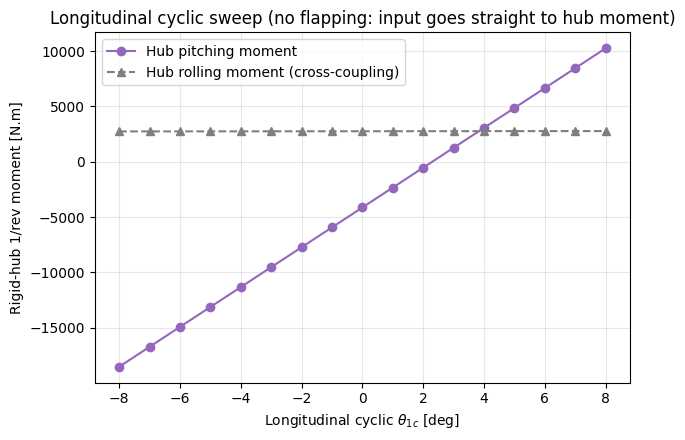

Hub pitch moment vs theta_1c slope: 1798.9 N.m/deg
Thrust variation over sweep: 45.6 N (should be small -- cyclic barely changes mean thrust)


In [3]:
theta1c_range = np.arange(-8.0, 8.0 + 1e-6, 1.0)
sweep = solver.sweep_cyclic(theta1c_range, base_flight, axis="1c")
save_csv(sweep, ["theta_1c_deg", "T", "Q", "hub_pitch_moment", "hub_roll_moment",
                  "reverse_flow_fraction", "stall_fraction"],
          os.path.join(OUT_DIR, "task4_2_theta1c_sweep.csv"))

plt.figure(figsize=(6.5, 4.5))
plt.plot(sweep["theta_1c_deg"], sweep["hub_pitch_moment"], "o-",
          color="tab:purple", label="Hub pitching moment")
plt.plot(sweep["theta_1c_deg"], sweep["hub_roll_moment"], "^--",
          color="tab:gray", label="Hub rolling moment (cross-coupling)")
plt.xlabel(r"Longitudinal cyclic $\theta_{1c}$ [deg]")
plt.ylabel("Rigid-hub 1/rev moment [N.m]")
plt.title("Longitudinal cyclic sweep (no flapping: input goes straight to hub moment)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task4_2_theta1c_sweep.png"), dpi=160)
plt.show()

slope = np.polyfit(theta1c_range, sweep["hub_pitch_moment"], 1)[0]
print(f"Hub pitch moment vs theta_1c slope: {slope:.1f} N.m/deg")
print(f"Thrust variation over sweep: {sweep['T'].max()-sweep['T'].min():.1f} N "
      f"(should be small -- cyclic barely changes mean thrust)")

## 4.3 -- Lateral cyclic (theta_1s) sweep

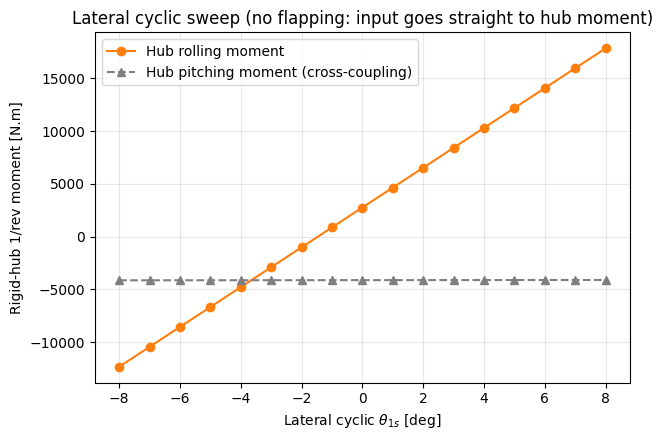

Hub roll moment vs theta_1s slope: 1887.9 N.m/deg


In [4]:
theta1s_range = np.arange(-8.0, 8.0 + 1e-6, 1.0)
sweep = solver.sweep_cyclic(theta1s_range, base_flight, axis="1s")
save_csv(sweep, ["theta_1s_deg", "T", "Q", "hub_pitch_moment", "hub_roll_moment",
                  "reverse_flow_fraction", "stall_fraction"],
          os.path.join(OUT_DIR, "task4_3_theta1s_sweep.csv"))

plt.figure(figsize=(6.5, 4.5))
plt.plot(sweep["theta_1s_deg"], sweep["hub_roll_moment"], "o-",
          color="tab:orange", label="Hub rolling moment")
plt.plot(sweep["theta_1s_deg"], sweep["hub_pitch_moment"], "^--",
          color="tab:gray", label="Hub pitching moment (cross-coupling)")
plt.xlabel(r"Lateral cyclic $\theta_{1s}$ [deg]")
plt.ylabel("Rigid-hub 1/rev moment [N.m]")
plt.title("Lateral cyclic sweep (no flapping: input goes straight to hub moment)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task4_3_theta1s_sweep.png"), dpi=160)
plt.show()

slope = np.polyfit(theta1s_range, sweep["hub_roll_moment"], 1)[0]
print(f"Hub roll moment vs theta_1s slope: {slope:.1f} N.m/deg")